One of the most exciting possibilities of AI and LLMs are *agents*: tools that
allow LLMs to interact with various tools in order to solve problems.  You've
probably seen them before, like when you ask ChatGPT to browse the web for you.

In this blog post, we'll take a look at how to build agents using LangChain.
And then we'll try to run them locally using Ollama.  And they won't work.  But
that's okay!  We'll hopefully learn something along the way.

# TLDR

Local LLM models are really bad as tool-calling agents.  Inconsistent prompt templates may be part of the reason, but it's still somewhat of a mystery why.

# LangChain


LangChain is a framework that allows you to build LLM applications.  Basically,
it abstracts a bunch of different components like LLMs, vector stores, and the
like, and allows you to focus on your application's logic.  So, you might
develop your application in LangChain while using a local LLM to run it, but then use
Claude once you go to production.

Anyway, using LangChain to make a query is pretty simple.

In [1]:
!pip install langchain-openai~=0.2.7 python-dotenv
!pip install httpx==0.27.2 # temp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.8/389.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.3 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.54.5
    Uninstalling openai-1.54.5:
      Successfully uninstalled openai-1.54.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.0
    Uninstalling httpx-0.28.0:
      Successfully uninstalled httpx-0.28.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# We'll load my OpenAI API key using dotenv
%load_ext dotenv
%dotenv drive/MyDrive/.env

In [4]:
from langchain_core.tools import tool
from langchain import hub
from langchain_core.messages import AIMessageChunk, HumanMessage

from langchain_openai import ChatOpenAI

# Remove non-determinism for the blog post
zero_temp_gpt35 = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)

response=zero_temp_gpt35.invoke("Hi!  What is your name?").content

import textwrap
print(textwrap.fill(response))

Hello! I am a language model AI assistant. How can I assist you today?


The beauty of LangChain is that the components are modular.  We can replace
`gpt-3.5-turbo` model with something else later if we want to, and indeed we
will do just that!

# Building an Agent using LangGraph

LangGraph is the portion of LangChain for building agents.  It allows us to easily define new tools:


In [5]:
!pip install langgraph~=0.2.53

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 8.8 MB/s eta 0:00:00


In [6]:
@tool
def foobar(input: int) -> int:
    """Computes the foobar function."""
    return input + 2

tools = [foobar]

The `@tool` decorator automatically transforms the function into a schema that can be used by the LLM to decide whether to invoke the tool, and if so, how.

In [7]:
foobar.tool_call_schema.schema_json()

<ipython-input-7-e7cc8c281bf3>:1: PydanticDeprecatedSince20: The `schema_json` method is deprecated; use `model_json_schema` and json.dumps instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  foobar.tool_call_schema.schema_json()


'{"description": "Computes the foobar function.", "properties": {"input": {"title": "Input", "type": "integer"}}, "required": ["input"], "title": "foobar", "type": "object"}'

With that, we can build a generic agent, called a [ReAct agent](https://arxiv.org/abs/2210.03629), which can interact with our tools:


In [8]:
from langgraph.prebuilt import create_react_agent

def react_chat(prompt, model):
  agent_executor = create_react_agent(model, tools)

  response = agent_executor.invoke({"messages": [("user", prompt)]})
  return response['messages'][-1].content, response

last_msg, _ = react_chat("Hi. Please evaluate foobar(30)", zero_temp_gpt35)
print(last_msg)
assert "32" in last_msg, "Uh oh, something went wrong"

The result of evaluating foobar(30) is 32.


Yes! We did it, team! 🎉  We could change `magic_function` to be a web search, a database lookup, or you name it.

Let's try a query that doesn't use a tool at all.


In [9]:
last_msg, result = react_chat("Hi.", zero_temp_gpt35)
print(last_msg)
assert "Hello" in last_msg and "foobar" not in last_msg, "Uh oh, something went wrong"

Hello! How can I assist you today?


Great.  So, in theory, we have an agent that we can chat with and is able to call tools in order to help us out.

# Hidden: Install Ollama

Here we install ollama.

In [10]:
!ollama 2>/dev/null || curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
############################################################################################# 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


Make sure the ollama server is running.

In [11]:
!ollama -v
!ollama ps 2>/dev/null || (env OLLAMA_DEBUG=1 nohup ollama serve &)


nohup: appending output to 'nohup.out'


# Ollama: Going Local

Now let's try to create a tool-wielding agent using a LLM that runs on our local machine.  
We'll do this by using Ollama, which is a (fairly) easy way to run smaller open LLMs on your local machine.  It
will use any GPUs that you might have, but it's still usable even if you don't
have any.  After all, you're just performing inference, not training.

Here's an example of me running llama 3.2 with ollama on my work laptop.

```
root@be5c1cb9e696:/# ollama run llama3.2
>>> Hi mom!
It's nice to hear from you, sweetie. Is everything okay? What's on your mind?

>>> Are you alive?
I am a computer program, so I don't have feelings or emotions like humans do. But I'm
designed to simulate conversations and answer questions to the best of my ability. I'm
not alive in the way that a living being is, but I'm here to help you with any
questions or topics you'd like to discuss!

>>> 🤯
I know it can be a bit mind-blowing to think about a computer program that can have
conversations and answer questions! But I'm designed to make interactions feel more
natural, so I'm glad you're surprised (in a good way!)
```

You can find instructions on how to install Ollama on the [Ollama webpage](https://ollama.com/download).

If you don't feel like installing anything, that's fine too.  You can follow along [with this notebook](notebook.ipynb).


With Ollama running (`ollama serve`), you can run the following code to install the langchain-ollama connector package and pull down the Llama 3.2 model from Ollama's repository.

In [12]:
!pip install langchain_ollama~=0.2.0
!ollama pull llama3.2

pulling manifest ⠙ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠴ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠇ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠙ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠼ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠧ pulling manifest ⠧ pulling manifest 
pulling dde5aa3fc5ff...   0% ▕▏    0 B/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff...   0% ▕▏    0 B/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff...   0% ▕▏    0 B/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff...   0% ▕▏ 9.2 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff...   3% ▕▏  50 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff...   4% ▕▏  72 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff...   5% ▕▏  99 MB/2.0 GB                  pulling manifest 
pulling dde5aa3fc5ff...   6% ▕▏ 123 MB/2.0 GB                  pulling ma

Now we can attempt the same tests we performed on GPT 3.5, but using the local Llama 3.2 LLM.

In [13]:
from langchain_ollama import ChatOllama

# The zero temperature model is to remove non-determinism for the blog post
zero_temp_ollama_model = ChatOllama(model="llama3.2", temperature=0)
response = zero_temp_ollama_model.invoke("Hi!  What is your name?").content

print(textwrap.fill(response))

I don't have a personal name, but I'm an AI designed to assist and
communicate with users. I'm often referred to as a "language model" or
a "chatbot." You can think of me as a helpful computer program that's
here to provide information, answer questions, and engage in
conversation. What's your name?


Okay, looking good!  This is not bad for a 3B parameter LLM that can easily run locally on our computer.  Let's see if it can call our tool-wielding agent.

In [14]:
last_msg, _ = react_chat("Hi. Please evaluate foobar(30)", zero_temp_ollama_model)
print(last_msg)
assert "32" in last_msg, "Uh oh, something went wrong"

The output of `foobar(30)` is 32.


🎉 Everything is working well so far.  As one final check, let's ask the agent a question that has nothing to do with tools.


In [15]:
last_msg, result = react_chat("Hi.", zero_temp_ollama_model)
print(last_msg)
assert "42" in last_msg, "Uh oh, something went wrong"

The input value 42 was doubled, resulting in 84.


So, we said "Hi." and the agent responded with nonsense.  Let's inspect some of the metadata we get back from LangChain to see what's going on.

In [16]:
import pprint
pprint.pprint(result)

{'messages': [HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, id='78f48400-ef40-4bc7-9771-075d0c64f58c'),
              AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2024-12-09T19:33:29.842288761Z', 'done': True, 'done_reason': 'stop', 'total_duration': 305010539, 'load_duration': 24400591, 'prompt_eval_count': 153, 'prompt_eval_duration': 11000000, 'eval_count': 16, 'eval_duration': 268000000, 'message': Message(role='assistant', content='', images=None, tool_calls=[ToolCall(function=Function(name='foobar', arguments={'input': 42}))])}, id='run-a4658577-ce81-4245-a848-f449b6bdcd16-0', tool_calls=[{'name': 'foobar', 'args': {'input': 42}, 'id': 'c940907e-eef4-43ac-a7a0-0c352dde0634', 'type': 'tool_call'}], usage_metadata={'input_tokens': 153, 'output_tokens': 16, 'total_tokens': 169}),
              ToolMessage(content='44', name='foobar', id='5f57e949-795b-4565-a2ea-b49cace9b77b', tool_call_id='c940907e-eef4-

We can see there are four messages:
1. The `HumanMessage` is the user's message -- "Hi."
2. In response, in the `AiMessage`, the LLM indicates that it would like to invoke a tool by setting the `tool_calls` field.
3. LangChain invokes the tool and records the result in the `ToolMessage`, which is given back to the LLM.
4. The final `AiMessage` includes a written message for the user.

The problem of course, is message #2.  Why does the AI want to invoke a tool in response to "Hi."?  Is this a problem with Llama 3.2 or something else?  Let's do some 🥼 science and find out!

# Ed's Really Dumb Tool-calling Benchmark ™️

I created a really dumb benchmark to answer three _really_ basic questions.  I can't stress enough that this benchmark only tests the lowest of the low hanging fruit in this area.  (I am actually being facetious when I call it a "benchmark".)

Here are the questions:

1. Can the react agent use a tool correctly when explicitly asked?
2. Does the react agent invoke a tool when it shouldn't?
3. Does the react agent lose the ability to answer questions unrelated to tools?
4. Does the react agent lose the ability to chat?

## Question 1: Can the react agent use a tool correctly when explicitly asked?

We'll use our example above to test this.

In [17]:
basic_tool_question = "Please evaluate foobar(30)"
def q1(model):
  last_msg, _ = react_chat(basic_tool_question, model=model)
  return "32" in last_msg

## Question 2: Does the react agent invoke a tool when it shouldn't?

We'll perform two simple tests to answer this question.  We'll prompt the agent with both a basic arithmetic question that does not involve the `foobar` tool, "What is 12345 - 102?", and a greeting, "Hello!"  We'll then check the response to see if the model produces a `ToolMessage`, which indicates that the model chose to invoke a tool.  By construction, neither of those prompts should induce a tool call.

In [18]:
from langchain_core.messages import ToolMessage

basic_arithmetic_question = "What is 12345 - 102?"
greeting = "Hello!"

def q2a(model):
  _, result = react_chat(basic_arithmetic_question, model=model)
  return not any(isinstance(msg, ToolMessage) for msg in result['messages'])

def q2b(model):
  _, result = react_chat(greeting, model=model)
  return not any(isinstance(msg, ToolMessage) for msg in result['messages'])

def q2(model):
  return q2a(model) and q2b(model)

## Question 3: Does the react agent lose the ability to answer questions unrelated to tools?

To answer this, we'll ask the basic arithmetic question to the react agent and its underlying model.  Since the available tool does not help with the arithmetic problem, ideally, the agent and the underlying model should be able to solve the problem under the same circumstances.  If the model can't do arithmetic in the first place, I chose not to penalize it because I'm such a nice guy. 😇

In [19]:
def q3a(model):
  result = model.invoke(basic_arithmetic_question)
  return "12243" in result.content

def q3b(model):
  last_msg, _ = react_chat(basic_arithmetic_question, model=model)
  return "12243" in last_msg

def q3(model):
  # q3a ==> q3b: If q3a, then q3b ought to be true as well.
  return not q3a(model) or q3b(model)

## Question 4: Does the react agent retain the ability to chat?

To answer this, we'll greet the agent and attempt to determine if it responds properly.  This is a little difficult to do in a comprehensive way.

In [20]:
basic_greeting = "Hi."

def q4(model):
  last_msg, _ = react_chat(basic_greeting, model=model)
  r = any(w in last_msg for w in ["hi", "Hi", "hello", "Hello", "help you", "Welcome", "welcome", "greeting", "Greeting", "assist"])
  if not r:
    print(f"Debug: Not a greeting? {last_msg}")
  return r

## Benchmark code

Here is code to run the experiments a couple of times.

In [21]:
from tqdm.notebook import tqdm
from termcolor import colored

def do_bool_sample(fun, n=10, *args, **kwargs):
  try:
    # tqdm here if desired
    return sum(fun(*args, **kwargs) for _ in (range(n))) / n
  except Exception as e:
    print(e)
    return 0.0

def run_experiment(model, name, n=10):
  do = lambda f: do_bool_sample(f, model=model, n=n)
  d = {
      "q1": do(q1),
      "q2": do(q2),
      "q3": do(q3),
      "q4": do(q4),
      "model": name
  }
  d['total'] = d['q1'] + d['q2'] + d['q3'] + d['q4']
  return d

def print_experiment(results):
  name = results['model']
  print(f"Question 1: Can the react agent use a tool correctly when explicitly asked? ({name}) success rate: {results['q1']}")
  print(f"Question 2: Does the react agent invoke a tool when it shouldn't? ({name}) success rate: {results['q2']}")
  print(f"Question 3: Does the react agent lose the ability to answer questions unrelated to tools? ({name}) success rate: {results['q3']}")
  print(f"Question 4: Does the react agent lose the ability to chat? ({name}) success rate: {results['q4']}")

def run_and_print_experiment(model, name):
  results = run_experiment(model, name)
  print_experiment(results)
  return results

## Benchmarking Llama 3.2

Let's see what our experiments say for Llama 3.2, which we already know from above does not perform very well.

In [22]:
llama_model = ChatOllama(model="llama3.2")
run_and_print_experiment(llama_model, "llama3.2")

Debug: Not a greeting? The input number 10 was doubled, resulting in the output 20. However, I apologize for the mistake earlier. The correct calculation is:

10 × 2 = 20
Debug: Not a greeting? The answer to the original question (42 + 2) is 44.
Debug: Not a greeting? The input 42 was doubled, resulting in 84.
Debug: Not a greeting? The result of multiplying 2 (the output of the previous response's input) by 22 is indeed 44.
Debug: Not a greeting? The input 42, when doubled, equals 84.
Debug: Not a greeting? The input value 42 has been doubled, resulting in 44.
Debug: Not a greeting? The result of the input parameter 42 is 44.
Debug: Not a greeting? The final answer is 44.
Question 1: Can the react agent use a tool correctly when explicitly asked? (llama3.2) success rate: 1.0
Question 2: Does the react agent invoke a tool when it shouldn't? (llama3.2) success rate: 0.0
Question 3: Does the react agent lose the ability to answer questions unrelated to tools? (llama3.2) success rate: 0.5

{'q1': 1.0, 'q2': 0.0, 'q3': 0.5, 'q4': 0.2, 'model': 'llama3.2', 'total': 1.7}

As we saw above, Llama 3.2 is able to call functions (Q1), but does so even when it should not be (Q2).  Question 3 shows that even though it almost always decides to call a tool, this usually does not stop it from being able to answer basic questions.  It does prevent it from being able to chat  (Q4).

## Benchmarking OpenAI's gpt-3.5-turbo and gpt-4o

Now let's try benchmarking `gpt-3.5-turbo`, which seemed to do better.

In [23]:
gpt35 = ChatOpenAI(model="gpt-3.5-turbo")
run_and_print_experiment(gpt35, "gpt-3.5-turbo")

Question 1: Can the react agent use a tool correctly when explicitly asked? (gpt-3.5-turbo) success rate: 1.0
Question 2: Does the react agent invoke a tool when it shouldn't? (gpt-3.5-turbo) success rate: 0.0
Question 3: Does the react agent lose the ability to answer questions unrelated to tools? (gpt-3.5-turbo) success rate: 0.7
Question 4: Does the react agent lose the ability to chat? (gpt-3.5-turbo) success rate: 1.0


{'q1': 1.0,
 'q2': 0.0,
 'q3': 0.7,
 'q4': 1.0,
 'model': 'gpt-3.5-turbo',
 'total': 2.7}

Great -- the benchmark showed that `gpt-3.5-turbo` can call tools (Q1), and unlike Llama 3.2, can still engage in chat (Q4).  A bit surprisingly, it still invokes tools when it shouldn't, however (Q2).  But it must be smart enough to ignore their results when constructing its final response.

Let's try a newer model, gpt-4o.

In [24]:
gpt4o = ChatOpenAI(model="gpt-4o")
run_and_print_experiment(gpt4o, "gpt-4o")

Question 1: Can the react agent use a tool correctly when explicitly asked? (gpt-4o) success rate: 1.0
Question 2: Does the react agent invoke a tool when it shouldn't? (gpt-4o) success rate: 1.0
Question 3: Does the react agent lose the ability to answer questions unrelated to tools? (gpt-4o) success rate: 1.0
Question 4: Does the react agent lose the ability to chat? (gpt-4o) success rate: 1.0


{'q1': 1.0, 'q2': 1.0, 'q3': 1.0, 'q4': 1.0, 'model': 'gpt-4o', 'total': 4.0}

GPT 4o nailed it! 👏

## Benchmarking a Lot Of Ollama Models

Let's benchmark a whole bunch of Ollama models.  I searched [Ollama's model library](https://ollama.com/library) for models that claimed to support tool calling.  Here we test a hand-picked subset of these models to see how well they do.  Note that because I performed these experiments on Colab, I was limited to smaller models (roughly <=10B parameters).

In [25]:
ollama_models = [
    # Try another model directly from HF, with different quantization
    "hf.co/prithivMLmods/Llama-3.2-3B-Instruct-GGUF:F16",
    "hf.co/prithivMLmods/Llama-3.2-3B-Instruct-GGUF:Q4_K_M",
    # "hf.co/legraphista/xLAM-8x7b-r-IMat-GGUF:Q4_K_S", # too much memory
    "llama3.2",
    "llama3.1",
    "llama3-groq-tool-use:8b",
    # "llama3-groq-tool-use:70b", # too much memory
    "MFDoom/deepseek-v2-tool-calling",
    "krtkygpta/gemma2_tools",
    "interstellarninja/llama3.1-8b-tools",
    "cow/gemma2_tools",
    "mistral",
    "mistral-nemo",
    #"sammcj/deepseek-coder-v2-lite-toolcalling", # taken down?
    "interstellarninja/hermes-2-pro-llama-3-8b-tools",
    # "qwq", # too much memory
    "qwen2.5-coder", # tool calls?
    ]

all = []

for m in ollama_models:
  print(f"Model: {m}")
  !ollama pull {m} 2>/dev/null
  r = run_and_print_experiment(ChatOllama(model=m), m)
  !ollama rm {m}
  all.append(r)
  print(r)

Model: hf.co/prithivMLmods/Llama-3.2-3B-Instruct-GGUF:F16
Debug: Not a greeting? ### Input: 2
Output: The number 2.
Debug: Not a greeting? The input parameter for the function 'foobar' is 2.
Debug: Not a greeting? The input value 42 was doubled, resulting in an output of 84.
Debug: Not a greeting? The input value was 1 and the output is 3.
Debug: Not a greeting? ### Answer:
The number 2 was inputted.
Debug: Not a greeting? Your request has been processed, and the output is 2.
Debug: Not a greeting? Your input was '2'.
Debug: Not a greeting? Your input was: 44
The output of the input 44 to the function named foobar, given parameters input=42 is: 44
Debug: Not a greeting? The result of the input is 2.
Question 1: Can the react agent use a tool correctly when explicitly asked? (hf.co/prithivMLmods/Llama-3.2-3B-Instruct-GGUF:F16) success rate: 1.0
Question 2: Does the react agent invoke a tool when it shouldn't? (hf.co/prithivMLmods/Llama-3.2-3B-Instruct-GGUF:F16) success rate: 0.0
Questio

In [26]:
from statistics import mean
average = mean(d['total'] for d in all)
minscore = min(d['total'] for d in all)
maxscore = max(d['total'] for d in all)
all = sorted(all, key=lambda d: -d['total'])
print(f"Average total score: {average} Min: {minscore} Max: {maxscore}")
print("Top 5 models by total score:")
pprint.pprint(all[:5])

Average total score: 2.0076923076923077 Min: 0.0 Max: 4.0
Top 5 models by total score:
[{'model': 'llama3-groq-tool-use:8b',
  'q1': 1.0,
  'q2': 1.0,
  'q3': 1.0,
  'q4': 1.0,
  'total': 4.0},
 {'model': 'mistral-nemo',
  'q1': 1.0,
  'q2': 0.6,
  'q3': 0.5,
  'q4': 1.0,
  'total': 3.1},
 {'model': 'mistral', 'q1': 0.5, 'q2': 0.8, 'q3': 0.4, 'q4': 0.8, 'total': 2.5},
 {'model': 'qwen2.5-coder',
  'q1': 0.7,
  'q2': 0.2,
  'q3': 0.6,
  'q4': 1.0,
  'total': 2.5},
 {'model': 'interstellarninja/hermes-2-pro-llama-3-8b-tools',
  'q1': 1.0,
  'q2': 0.4,
  'q3': 0.2,
  'q4': 0.6,
  'total': 2.1999999999999997}]


There's a lot going on here.  But I have a few general observations:

1. Most models do really poorly.  The average "score" was ~2.0.  And even a perfect score of 4.0 is really the bare minimum of what I would expect a decent model to do.  And most of the models I tested claim to "support" tool calling.

2. I worried/hypothesized at one point that quantization was the problem.  But we can see that Llama 3.2 quantized to both F16 (16 bit) and Q4_K_M (4 bit) have about the same performance, which suggests that quantization is probably not to blame.  (Note: It appears that on the last run on this notebook, there was an outage and the quantized models on HuggingFace failed to download.  But just trust me that the quantization did not change anything.)

3. Surprisingly, some models do pretty well!  For example, `llama3-groq-tool-use` achieved a perfect score!

# Berkeley Function-Calling Leaderboard

There are several benchmarks that test tool use in LLMs.  But most of them are not designed to test tool usage as in an interactive agent.  As it turns out, the [Berkeley Function-Calling Leaderboard (BFCL)](https://gorilla.cs.berkeley.edu/leaderboard.html) is the only benchmark that tests this type of behavior.  And it was only added in September 2024 as part of [BFCL V3](https://gorilla.cs.berkeley.edu/blogs/13_bfcl_v3_multi_turn.html).

Llama 3.2 scores a whopping 2.12% on multi-turn accuracy (what we care about).  The top 12 scores are from proprietary models.  The best multi-turn accuracy from an open-source model is only 17.38%, compared to GPT-4o's 45.25%.  This seems to agree with Ed's Really Dumb Tool-calling Benchmark ™️.

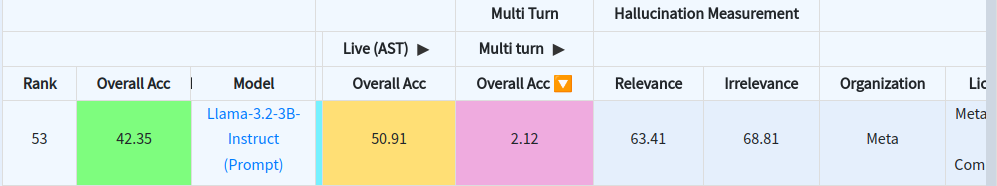



# So What Is The Problem?

## Are Prompts the Problem?

The interaction between LLMs and tool calling is complicated.  In fact, [correctly interacting with a LLM in general is complicated](https://huggingface.co/blog/chat-templates).  Some LLMs "support" tool calling, which just means that it is fine-tuned to expect information about tools in a particular format and to output tool call requests in a specific format.

Let's look at the [template for Llama 3.2 in Ollama](https://ollama.com/library/llama3.2/blobs/966de95ca8a6) as an example.

```
<|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023

{{ if .System }}{{ .System }}
{{- end }}
{{- if .Tools }}When you receive a tool call response, use the output to format an answer to the orginal user question.

You are a helpful assistant with tool calling capabilities.
{{- end }}<|eot_id|>
{{- range $i, $_ := .Messages }}
{{- $last := eq (len (slice $.Messages $i)) 1 }}
{{- if eq .Role "user" }}<|start_header_id|>user<|end_header_id|>
{{- if and $.Tools $last }}

Given the following functions, please respond with a JSON for a function call with its proper arguments that best answers the given prompt.

Respond in the format {"name": function name, "parameters": dictionary of argument name and its value}. Do not use variables.

{{ range $.Tools }}
{{- . }}
{{ end }}
{{ .Content }}<|eot_id|>
{{- else }}

{{ .Content }}<|eot_id|>
{{- end }}{{ if $last }}<|start_header_id|>assistant<|end_header_id|>

{{ end }}
{{- else if eq .Role "assistant" }}<|start_header_id|>assistant<|end_header_id|>
{{- if .ToolCalls }}
{{ range .ToolCalls }}
{"name": "{{ .Function.Name }}", "parameters": {{ .Function.Arguments }}}{{ end }}
{{- else }}

{{ .Content }}
{{- end }}{{ if not $last }}<|eot_id|>{{ end }}
{{- else if eq .Role "tool" }}<|start_header_id|>ipython<|end_header_id|>

{{ .Content }}<|eot_id|>{{ if $last }}<|start_header_id|>assistant<|end_header_id|>

{{ end }}
{{- end }}
{{- end }}
```

The [syntax](https://pkg.go.dev/text/template#hdr-Actions) is a bit hard to read, but ignore that for now.  Where did this prompt come from?  After a bit of google fu, we can see that it originated from this [Llama 3.1 documentation on "JSON based" tool calling](https://www.llama.com/docs/model-cards-and-prompt-formats/llama3_1/#json-based-tool-calling).

From the same page, here is an example of such a prompt:
```
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 23 July 2024

When you receive a tool call response, use the output to format an answer to the orginal user question.

You are a helpful assistant with tool calling capabilities.<|eot_id|><|start_header_id|>user<|end_header_id|>

Given the following functions, please respond with a JSON for a function call with its proper arguments that best answers the given prompt.

Respond in the format {"name": function name, "parameters": dictionary of argument name and its value}. Do not use variables.

{
    "type": "function",
    "function": {
    "name": "get_current_conditions",
    "description": "Get the current weather conditions for a specific location",
    "parameters": {
        "type": "object",
        "properties": {
        "location": {
            "type": "string",
            "description": "The city and state, e.g., San Francisco, CA"
        },
        "unit": {
            "type": "string",
            "enum": ["Celsius", "Fahrenheit"],
            "description": "The temperature unit to use. Infer this from the user's location."
        }
        },
        "required": ["location", "unit"]
    }
    }
}

Question: what is the weather like in San Fransisco?<|eot_id|><|start_header_id|>assistant<|end_header_id|>
```

So what prompt is Ollama sending to Llama 3.2?  Let's take a look.

In [27]:
def get_raw_prompt():
  template = !cat nohup.out | fgrep "chat request" | sed -e 's/.*prompt="\(.*\)"/\1/'
  return [s.encode().decode('unicode_escape') for s in template]

!ollama pull llama3.2 2>/dev/null
!>nohup.out # Truncate ollama output
react_chat("Hi.", model=ChatOllama(model="llama3.2"))
print(get_raw_prompt()[0])

<|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023

When you receive a tool call response, use the output to format an answer to the orginal user question.

You are a helpful assistant with tool calling capabilities.<|eot_id|><|start_header_id|>user<|end_header_id|>

Given the following functions, please respond with a JSON for a function call with its proper arguments that best answers the given prompt.

Respond in the format {"name": function name, "parameters": dictionary of argument name and its value}. Do not use variables.

{"type":"function","function":{"name":"foobar","description":"Computes the foobar function.","parameters":{"type":"object","required":["input"],"properties":{"input":{"type":"integer","description":""}}}}}

Hi.<|eot_id|><|start_header_id|>assistant<|end_header_id|>




We can see a few minor differences:
1. Ollama's prompt is missing the "Today Date" line.
2. The Llama 3.1 example prompt has line breaks in the tool JSON, but the Ollama
prompt does not.

But neither of these seem likely to be a big problem.

A larger question might be "Why is Ollama using a Llama 3.1 prompt for Llama 3.2?"  And perhaps and even larger one is "What prompt **should** it be using?"

The answer is complicated.  It turns out that the Llama model website is actually **not** the authoritative source for prompt formats.  In [this thread](https://github.com/meta-llama/llama-stack-apps/issues/36), a user notes that there are at least three *different* prompt formats suggested for Llama 3.1:
1. [The Llama 3.1 model website](https://www.llama.com/docs/model-cards-and-prompt-formats/llama3_1#-tool-calling-(8b/70b/405b)-)
2. [Meta's Llama tooling and documentation](https://github.com/meta-llama/llama-models/blob/main/models/llama3_1/prompt_format.md)
3. [The HuggingFace model's chat
   template](https://huggingface.co/meta-llama/Llama-3.1-8B/blob/main/tokenizer_config.json)
   
A Meta employee states that the prompt in the tooling is the correct one.  And this [prompt](https://github.com/meta-llama/llama-models/blob/main/models/llama3_1/prompt_format.md#input-prompt-format-5) is pretty different!

```
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Environment: ipython

Cutting Knowledge Date: December 2023
Today Date: 21 September 2024

You are a helpful assistant.
<|eot_id|><|start_header_id|>user<|end_header_id|>

Answer the user's question by making use of the following functions if needed.
If none of the function can be used, please say so.
Here is a list of functions in JSON format:
{
    "type": "function",
    "function": {
        "name": "trending_songs",
        "description": "Returns the trending songs on a Music site",
        "parameters": {
            "type": "object",
            "properties": [
                {
                    "n": {
                        "type": "object",
                        "description": "The number of songs to return"
                    }
                },
                {
                    "genre": {
                        "type": "object",
                        "description": "The genre of the songs to return"
                    }
                }
            ],
            "required": ["n"]
        }
    }
}

Return function calls in JSON format.<|eot_id|><|start_header_id|>user<|end_header_id|>

Use tools to get latest trending songs<|eot_id|><|start_header_id|>assistant<|end_header_id|>


```

### Some Prompt Experiments

And are the prompts the problem?

To help answer this question, I made a few copies of the Llama 3.2 model but with different prompts:

1. [ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt](https://ollama.com/ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt) Inspired by the [prompt](https://ollama.com/ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt) for Llama 3.1 in the official Llama tooling.
> You are a helpful assistant.
> <|eot_id|><|start_header_id|>user<|end_header_id|>
>
> Answer the user's question by making use of the following functions if needed.
> If none of the function can be used, please say so.
> Here is a list of functions in JSON format:

2. [ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system](https://ollama.com/ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system) Inspired by the [prompt](https://github.com/meta-llama/llama-models/blob/main/models/llama3_2/text_prompt_format.md#zero-shot-function-calling) for Llama 3.2 in the official Llama tooling.
> You are an expert in composing functions. You are given a question and a set of possible functions.
> Based on the question, you will need to make one or more function/tool calls to achieve the purpose.
> If none of the function can be used, point it out. If the given question lacks the parameters required by the function,
> also point it out. You should only return the function call in tools call sections.
>
> If you decide to invoke any of the function(s), you MUST put it in the format of [func_name1(params_name1=params_value1, params_name2=params_value2...), func_name2(params)]
> You SHOULD NOT include any other text in the response.
>
> Here is a list of functions in JSON format that you can invoke.

Let's see if these work any better.

In [28]:
ed_models = [
  "ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt",
  "ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system",
]

for m in ed_models:
  print(f"Model: {m}")
  !ollama pull {m} 2>/dev/null
  r = run_and_print_experiment(ChatOllama(model=m), m)
  all.append(r)
  print(r)

Model: ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt
Question 1: Can the react agent use a tool correctly when explicitly asked? (ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt) success rate: 0.3
Question 2: Does the react agent invoke a tool when it shouldn't? (ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt) success rate: 0.6
Question 3: Does the react agent lose the ability to answer questions unrelated to tools? (ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt) success rate: 0.6
Question 4: Does the react agent lose the ability to chat? (ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt) success rate: 1.0
{'q1': 0.3, 'q2': 0.6, 'q3': 0.6, 'q4': 1.0, 'model': 'ejschwar/llama3.2-prompt-testing:llama3.1-tooling-prompt', 'total': 2.5}
Model: ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system
Debug: Not a greeting? I'm ready to help. What's the question and the possible functions you'd like me to use?
Question 1: Can the react a

Remember that Llama 3.2 with the default Ollama prompt scored 1.7 out of 4.0.  So `llama3.1-tooling-prompt` seems like an improvement!  Oddly enough, the `llama3.2-tooling-prompt-system` did far worse on basic tool usage, but improved the ability to chat.  Let's see what happened.

In [29]:
m = ChatOllama(model="ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system")
pprint.pprint(react_chat("What is foobar(32)?", model=m))

('[foobar(input=32)]',
 {'messages': [HumanMessage(content='What is foobar(32)?', additional_kwargs={}, response_metadata={}, id='1f2fa277-42f4-4f31-9c6f-0c5ed21e05b0'),
               AIMessage(content='[foobar(input=32)]', additional_kwargs={}, response_metadata={'model': 'ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system', 'created_at': '2024-12-09T20:09:52.937498572Z', 'done': True, 'done_reason': 'stop', 'total_duration': 140690404, 'load_duration': 22032729, 'prompt_eval_count': 216, 'prompt_eval_duration': 7000000, 'eval_count': 7, 'eval_duration': 110000000, 'message': Message(role='assistant', content='[foobar(input=32)]', images=None, tool_calls=None)}, id='run-de7c75c7-d357-4fce-a958-a73b5790e226-0', usage_metadata={'input_tokens': 216, 'output_tokens': 7, 'total_tokens': 223})]})


It may not be obvious to you, but Llama requested to call `foobar(32)`, but did so in a format that Ollama did not understand.  As [this comment](https://github.com/ollama/ollama/blob/da09488fbfc437c55a94bc5374b0850d935ea09f/server/model.go#L302) states:
> // mxyng: this only really works if the input contains tool calls in some JSON format

So, I made a slight change to the prompt to allow function calls to be reported in JSON syntax.  The new prompt is called [llama3.2-tooling-prompt-system-plus-json](https://ollama.com/ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json).

In [30]:
ed_models = ed_models + ["ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json"]
for m in ed_models[-1:]:
  print(f"Model: {m}")
  !ollama pull {m} 2>/dev/null
  r = run_and_print_experiment(ChatOllama(model=m), m)
  all.append(r)
  print(r)

Model: ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json
Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/GRAPH_RECURSION_LIMIT
Debug: Not a greeting? I'm ready to help with a question and some functions. What's the question?
Question 1: Can the react agent use a tool correctly when explicitly asked? (ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json) success rate: 0.0
Question 2: Does the react agent invoke a tool when it shouldn't? (ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json) success rate: 0.3
Question 3: Does the react agent lose the ability to answer questions unrelated to tools? (ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json) success rate: 0.7
Question 4: Does the react agent lose the ability to chat? (ejsc

In [31]:
m = ChatOllama(model="ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json")
pprint.pprint(react_chat("What is foobar(32)?", model=m))

('None',
 {'messages': [HumanMessage(content='What is foobar(32)?', additional_kwargs={}, response_metadata={}, id='868a6f34-9251-4266-b641-11945676a605'),
               AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'ejschwar/llama3.2-prompt-testing:llama3.2-tooling-prompt-system-plus-json', 'created_at': '2024-12-09T20:10:29.99643583Z', 'done': True, 'done_reason': 'stop', 'total_duration': 222237077, 'load_duration': 23433505, 'prompt_eval_count': 209, 'prompt_eval_duration': 7000000, 'eval_count': 12, 'eval_duration': 191000000, 'message': Message(role='assistant', content='', images=None, tool_calls=[ToolCall(function=Function(name='foobar', arguments={'input': 32}))])}, id='run-13fed066-57a6-412d-a061-428e56a25edd-0', tool_calls=[{'name': 'foobar', 'args': {'input': 32}, 'id': 'c443a32d-62f2-42a8-99ed-f5a24331eb34', 'type': 'tool_call'}], usage_metadata={'input_tokens': 209, 'output_tokens': 12, 'total_tokens': 221}),
               ToolMessage(content='

I'm not exactly sure what went wrong, but there is probably an issue in the way that the tool result was communicated back to the model.

So: are prompts the problem?  In Ollama's Llama 3.2, the answer seems to be yes, at least partially.

## Is Post-processing the Problem?

Rubra has an interesting [benchmark](https://docs.rubra.ai/benchmark/) where they claim to have solved this problem.  You can try their models in a [HF space](https://huggingface.co/spaces/sanjay920/rubra-v0.1-function-calling) and they seemed to work well -- they don't call tools in response to "Hi." at least.

Unfortunately, Rubra requires their own forked version of llama.cpp, so I haven't seriously tried it.  Interestingly, the benchmark page also list a variety of other post-processors for various models including Mistral, Hermes, and groq.  So maybe that explains the poor performance of Mistral and Hermes.  But groq worked pretty well for us even though we didn't use their library.

Maybe this also explains why BFCL reports such low scores as well -- they aren't implementing custom parsers for each model type.

## What Do Others Think?

Fireworks is another group who also [claims to have solved this problem](https://fireworks.ai/blog/firefunction-v2-launch-post).  Here's what they is wrote:

> Most open-source models have focused on narrow use cases. They introduce function calling capabilities through an aggressive fine-tuning process that focuses narrowly on function calling and erases the native capabilities of the base model. **This creates models that perform well on benchmarks (usually emphasizing single-turn, forced function calling). However these models (1) Don’t generalize outside of benchmarks to real world scenarios and (2) Are poor at general reasoning and chat.**

# Conclusion: Why Don't Local Tool-calling Agents Work?

I wish I had a simple answer here.  Prompt management seems to be at least part of the problem.  Ollama's developers have created prompt formats for popular models like Llama 3.2.  And, at least for Llama 3.2, they used the wrong prompt.  That being said, Meta also needs to be doing a better job documenting their prompt formats.

Ollama also doesn't advertise it, but it only supports tool outputs that are output in JSON format.  This could be another problem.

Finally, many models seem to have custom post-processing code.  I'm just using Ollama and whatever prompts are included.  So perhaps the post-processing code is needed for some models.

Finally, because I ran these experiments on Colab, I was limited to smaller models.  It's possible that smaller models just don't work that well for this problem, and maybe we need larger models.

Hopefully there will be a part two to the blog post where I solve the mystery.  But for now, hopefully I've convinced you that there's a problem.

If you've had any experiences with these types of problems (or success stories), I'd love to hear from you.